---
#<font color="#CA3532">Neurocomputing Practice 3 – Academic Year 2025–2026</font>
### School of Engineering – Autonomous University of Madrid

---
- Start date: Thursday, 08-04-2026
- Submission deadline: Thursday, 05-05-2023

---

Last updated: 01-04-2026

In [1]:
### Incluid vuestros nombres, pareja y grupo aquí:
estudiantes = [
    {'nombre': 'nombre del primer estudiante'},
    {'nombre': 'nombre del segundo estudiante'}
]

Many binary classification problems do not have the same number of examples for each class. In these cases, the class distribution is said to be biased or unbalanced.

An example of this problem is found in speech recognizers that classify vowel sounds in European languages as either nasal or oral. Accuracy in classification is important for both classes, but it cannot be used in problems with unbalanced classes.

# <font color="#CA3532">Phoneme Dataset</font>


To characterize each vowel, five different attributes have been selected: the amplitudes of the first five harmonics (AHi), normalized by the total energy (Ene): AHi/Ene. Each harmonic can be positive if it corresponds to a local maximum in the spectrum, or negative otherwise.

In the *Phoneme Dataset*, there are two classes for the two types of sounds:
*	Class 0: nasal vowels (the majority class).
*	Class 1: oral vowels (the minority class).


In [2]:
# Details https://raw.githubusercontent.com/jbrownlee/Datasets/master/phoneme.names
dataset_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/phoneme.csv'

# <font color="#CA3532">Exploración de los datos</font>

In [4]:
from pandas import read_csv
from pandas import DataFrame
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
from collections import Counter

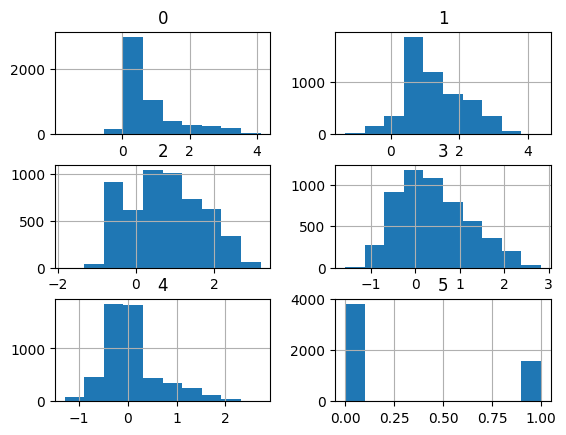

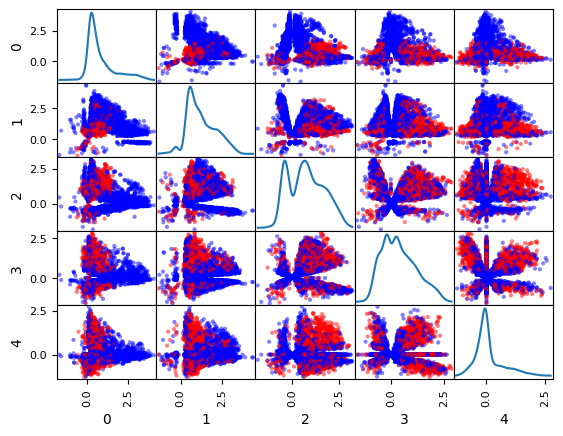

In [6]:
# define the dataset location
filename = dataset_url
# load the csv file as a data frame
df = read_csv(filename, header=None)
# histograms of all variables
df.hist()
pyplot.show()
# define a mapping of class values to colors
color_dict = {0:'blue', 1:'red'}
# map each row to a color based on the class value
colors = [color_dict[x] for x in df.values[:, -1]]
# drop the target variable
inputs = DataFrame(df.values[:, :-1])
# pairwise scatter plots of all numerical variables scatter_matrix(inputs, diagonal='kde', color=colors)
scatter_matrix(inputs, diagonal='kde', color=colors)
pyplot.show()

### Question 1: What is the class distribution of examples?  
Explain here what the previous plots represent and what you observe in them.

**Respuesta:**

**1. Histogramas univariantes (Primera figura):** 
Representan la distribución de frecuencias de cada una de las 6 variables del conjunto de datos. Las gráficas del 0 al 4 corresponden a las características de entrada (amplitudes de los armónicos), y la última a la clase objetivo.
*   **Variables 0, 1 y 4:** Presentan distribuciones numéricas continuas con sesgo positivo (asimetría hacia la derecha). La mayor concentración de datos se encuentra en torno a 0.
*   **Variable 2:** Muestra una distribución continua con una fuerte dispersión y ligera tendencia bimodal. Su rango aproximado es de $[-2, 3]$.
*   **Variable 3:** Tiene una distribución continua con forma pseudo-normal (acampanada), centrada en 0.
*   **Variable 5 (Clase objetivo):** El histograma de frecuencias discretas en 0 y 1 muestra explícitamente un **desbalanceo de clases severo**. La clase 0 (vocales nasales, la clase mayoritaria) agrupa aproximadamente 3800 muestras, frente a unas 1500 muestras de la clase 1 (vocales orales, minoritaria).

**2. Matriz de dispersión o Scatter Matrix (Segunda figura):** 
Muestra todas las combinaciones de pares posibles entre las 5 características de entrada.
*   **Diagonal principal:** Muestra la estimación de densidad de kernel (KDE) univariante para las 5 características de entrada, coincidiendo y suavizando las formas de los histogramas de la primera figura.
*   **Gráficos fuera de la diagonal (Dispersión bidimensional):** Reflejan cruces de variables por pares, con los puntos coloreados según su clase (Azul = Clase 0, Rojo = Clase 1).
*   **Separabilidad:** Se observa una superposición espacial masiva entre las clases en todas las proyecciones 2D. No existe una separabilidad lineal evidente en ninguno de los pares, lo que indica que es un problema de clasificación complejo no resoluble mediante fronteras de decisión simples.
*   **Varianza:** La clase 0 (azul) exhibe sistemáticamente una mayor varianza y amplitud en el espacio de características, mientras que la clase 1 (roja) tiende a concentrarse en densidades más cerradas.
*   **Estructuras de correlación:** Se aprecian distribuciones conjuntas con topologías no lineales fuertemente estructuradas (agrupaciones en forma de "V" o "X"), que son particularmente notorias en las intersecciones de las variables 2, 3 y 4.

# <font color="#CA3532">Modelling</font>

- In this practice, we will use [Keras](https://keras.io/)

- Keras is an open-source neural network library designed for experimenting with deep neural networks. Keras is modular, extensible, and easy to use.

- Keras can run on different backends. Here, it will be used with TensorFlow.

In [10]:
# Imports

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

import keras as k
from keras.models import Sequential
from keras.layers import Dense

from sklearn.preprocessing import StandardScaler

In [11]:
dataset = np.loadtxt(dataset_url, delimiter=',')

print(dataset)

### -------------------------------------------------------------------------------
### Split the examples into features and classes. Store the number of features.
### -------------------------------------------------------------------------------

x = dataset[:, :-1]
x_size = x.shape[1]
y = dataset[:, -1]

[[ 1.24   0.875 -0.205 -0.078  0.067  0.   ]
 [ 0.268  1.352  1.035 -0.332  0.217  0.   ]
 [ 1.567  0.867  1.3    1.041  0.559  0.   ]
 ...
 [ 1.031  0.584  1.866  1.532 -0.671  1.   ]
 [ 0.15   0.933  2.363 -0.742 -0.617  0.   ]
 [ 0.137  0.714  1.35   0.972 -0.63   1.   ]]


In [12]:
# Results of the split and the number of features
print(x)
print(y)
print(x_size)

[[ 1.24   0.875 -0.205 -0.078  0.067]
 [ 0.268  1.352  1.035 -0.332  0.217]
 [ 1.567  0.867  1.3    1.041  0.559]
 ...
 [ 1.031  0.584  1.866  1.532 -0.671]
 [ 0.15   0.933  2.363 -0.742 -0.617]
 [ 0.137  0.714  1.35   0.972 -0.63 ]]
[0. 0. 0. ... 1. 0. 1.]
5


In [13]:
# Normalize the data (if necessary)
scaler = StandardScaler()
scaler.fit(x)
x = scaler.transform(x)

## <font color="#CA3532">Neural Network Definition</font>

- Each layer of the model has a set of defined properties (size, activation function, connectivity, etc.) which you can find at https://keras.io/api/layers/core_layers/dense/.

- We will use Keras' Sequential model to create a multi-layer feedforward neural network.


In [16]:
# Define the model with Keras
from keras.layers import Dropout, Input

nn = Sequential()

### -------------------------------------------------------------------------------
### Add the fully connected layers you consider appropriate to the model
### -------------------------------------------------------------------------------

# 1. Capa Input
nn.add(Input(shape=(x_size,)))

# Arquitectura más profunda: aumentamos neuronas y cambiamos la activación a ReLU (aprende mejor)
nn.add(Dense(32, activation="relu"))
# Añadimos Dropout para apagar aleatoriamente neuronas y evitar sobreajuste (overfitting)
nn.add(Dropout(0.2))
# Añadimos una capa oculta extra
nn.add(Dense(16, activation="relu"))

# Capa de salida: 1 neurona porque es clasificación binaria (siempre en sigmoid)
nn.add(Dense(1, activation="sigmoid"))

## <font color="#CA3532">Neural Network Compilation</font>

- Compilation is the operation that builds the neural network.

- Compilation includes aspects that will be taken into account during the training of the neural network.

- In the sections below, you will find links to the official documentation where you can learn more about the different strategies for each aspect.

- It is also possible to define your own functions.

#### <font color="#CA3532">Optimizer</font>

The optimizer is the strategy used to compute weight updates.

https://keras.io/api/optimizers/

In [17]:
optimizer = "Adam"
# optimizer = "SGD"

#### <font color="#CA3532">Loss Function</font>

The loss function calculates the quantity the model aims to minimize during training.

https://keras.io/api/losses/

In [18]:
# loss = "mse"
loss = "binary_crossentropy"

#### <font color="#CA3532">Metrics</font>

A metric is a function that evaluates the performance of the model. Metrics are similar to loss functions, but unlike loss functions, they are not used during training—they are applied to the results. Loss functions can also be used as metrics.

https://keras.io/api/metrics/

In [19]:
metrics = [
            #keras.metrics.TruePositives(name='tp'),
            #keras.metrics.FalsePositives(name='fp'),
            #keras.metrics.TrueNegatives(name='tn'),
            #keras.metrics.FalseNegatives(name='fn'),
            keras.metrics.BinaryAccuracy(name='ACC'),
            keras.metrics.Precision(name='P'),
            keras.metrics.Recall(name='R'),
            keras.metrics.AUC(name='auc'),
            keras.metrics.AUC(name='PRC', curve='PR'),
          ]

In [20]:
# nn.compile(optimizer='SGD', loss="mse", metrics="accuracy")
nn.compile(optimizer=optimizer, loss=loss, metrics=metrics)

### Question 2: Explain in detail the metrics and loss functions that are relevant for this problem and describe how they are calculated. Explain why *accuracy* is not a good metric for unbalanced problems. What are ROC and PR curves, and what are they used for?

**Respuesta:**

**1. Funciones de Pérdida (Loss Functions) relevantes:**
Para este problema de clasificación binaria ("vocales nasales" vs "vocales orales"), la función de pérdida por defecto más adecuada es la **Entropía Cruzada Binaria (Binary Crossentropy)**. 
- *Cómo se calcula:* Penaliza las predicciones del modelo comparando la probabilidad predicha (entre 0 y 1) con la clase real (0 o 1). Matemáticamente, utiliza el logaritmo de las probabilidades predichas: $L = - \frac{1}{N} \sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$. Si el modelo asegura con alta probabilidad una predicción que resulta ser incorrecta, la penalización crece exponencialmente. Esta función es fundamental porque penaliza la incertidumbre de las predicciones, obligando al modelo no solo a acertar, sino a hacerlo con confianza.
- *Otras funciones relevantes:* En contextos de alto desbalanceo como este, también sería muy relevante usar **Focal Loss** (una variante avanzada de crossentropy). Focal Loss añade un factor que reduce dinámicamente el peso de los ejemplos que el modelo ya acierta fácilmente (generalmente la enorme clase mayoritaria), forzando a la red a "enfocarse" intensamente en aprender los casos difíciles (la clase minoritaria).

**2. Métricas relevantes configuradas en el modelo:**
Dado el desbalanceo, nos interesan métricas específicas (como las definidas en el vector `metrics`) que evalúen bien a la clase minoritaria:
- **BinaryAccuracy (ACC - Exactitud):** La proporción total de aciertos (`(TP + TN) / Total`).
- **Precision (Precisión):** Representa "De todos los que predije como clase oral (1), ¿cuántos lo eran realmente?". Se calcula como: `Verdaderos Positivos / (Verdaderos Positivos + Falsos Positivos)`.
- **Recall (Sensibilidad):** Representa "De todas las vocales orales reales (1), ¿cuántas logró detectar mi modelo?". Se calcula como: `Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos)`.
- **AUC (ROC AUC):** Calcula el área bajo la curva ROC (Receiver Operating Characteristic). Ofrece una medida agregada del rendimiento en todos los umbrales de clasificación.
- **AUC PRC (Área bajo la curva Precision-Recall):** Calcula el área para la curva de Precisión y Recall, que omite los Verdaderos Negativos. Superar esta métrica constata que el modelo maneja excepcionalmente bien la clase positiva minoritaria sin verse sesgado por la mayoritaria.

**3. Por qué la Exactitud (Accuracy) no es buena en problemas desbalanceados:**
La *exactitud* mide la proporción total de predicciones correctas (`Aciertos Totales / Total de Ejemplos`). En un dataset donde la clase 0 representa (por ejemplo) el 80% de los datos y la clase 1 el 20%, un modelo "ciego" que predeciría siempre la clase 0 obtendría un **80% de exactitud**. Esto daría la falsa sensación de ser un gran modelo, cuando en la práctica fracasa rotundamente localizando a la clase minoritaria (0% de Recall para la clase 1).

**4. Curvas ROC y PR (Precision-Recall):**
Para tomar una decisión final, la neurona de salida emite una probabilidad y necesita un "umbral" (usualmente 0.5) para elegir clase. Las curvas se utilizan para evaluar esto sin atarnos a un solo umbral:
- **Curva ROC:** Muestra la relación entre la *Tasa de Verdaderos Positivos* (Recall) y la *Tasa de Falsos Positivos* a lo largo de todos los umbrales posibles (de 0 a 1). Se resume calculando el área bajo la curva (AUC).
- **Curva PR:** Muestra la relación directa entre la *Precision* y el *Recall* a lo largo de distintos umbrales. **Se utiliza principalmente en conjuntos de datos muy desbalanceados**, porque estas dos métricas no incluyen en su cálculo a los Verdaderos Negativos. Evalúa cuán bien el modelo rinde *exclusivamente* en concentrarse en los casos positivos (la clase minoritaria que realmente importa), sin verse maquillado por la sobreabundancia de la clase mayoritaria.

## <font color="#CA3532">Neural Network Training</font>

The "fit" method trains a neural network with the provided data.

We will use 20% of the data for validation, although other validation methods are allowed, including parameter optimization.

https://keras.io/api/models/model_training_apis/#fit-method

In [21]:
from sklearn.model_selection import train_test_split

# Hacemos la partición de los datos. Se recomienda usar stratify=y para 
# mantener la proporción de la clase minoritaria en entrenamiento y validación.
# También fijamos un random_state para reproducibilidad.
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

# Entrenamos el modelo. 
# Hemos puesto verbose=1 para que puedas ver el progreso del entrenamiento.
# Aumentamos los epochs a 50 para darle suficiente tiempo a la red neuronal profunda a aprender y estabilizarse.
history = nn.fit(x_train, y_train, epochs=50, verbose=1, validation_data=(x_val, y_val))

# Mostramos el resumen de la arquitectura de la red
nn.summary()

Epoch 1/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - ACC: 0.7351 - P: 0.5777 - PRC: 0.5558 - R: 0.3633 - auc: 0.7702 - loss: 0.5197 - val_ACC: 0.7475 - val_P: 0.5973 - val_PRC: 0.6266 - val_R: 0.4259 - val_auc: 0.8168 - val_loss: 0.4614
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - ACC: 0.7772 - P: 0.6545 - PRC: 0.6481 - R: 0.5106 - auc: 0.8472 - loss: 0.4324 - val_ACC: 0.7771 - val_P: 0.6226 - val_PRC: 0.6430 - val_R: 0.6088 - val_auc: 0.8311 - val_loss: 0.4451
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - ACC: 0.7913 - P: 0.6546 - PRC: 0.6699 - R: 0.6123 - auc: 0.8585 - loss: 0.4155 - val_ACC: 0.7845 - val_P: 0.6329 - val_PRC: 0.6612 - val_R: 0.6309 - val_auc: 0.8430 - val_loss: 0.4321
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - ACC: 0.7911 - P: 0.6500 - PRC: 0.6964 - R: 0.6249 - auc: 0.8624 - loss: 0.4103 - val_ACC: 0.7845 - val_P: 0.6273 - val_PRC: 0.6714 - val_R: 0.6530 - val_auc: 0.8506 - val_loss: 0.4216
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,213 (8.65 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,476 (5.77 KB)

## <font color="#CA3532">Training Results Visualization</font>

- The *history* object stores the results of each epoch.

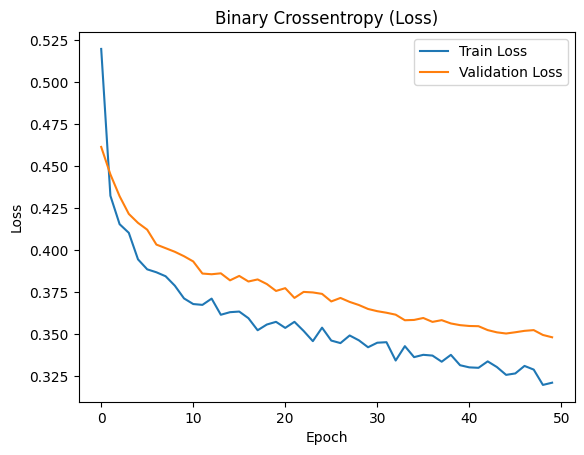

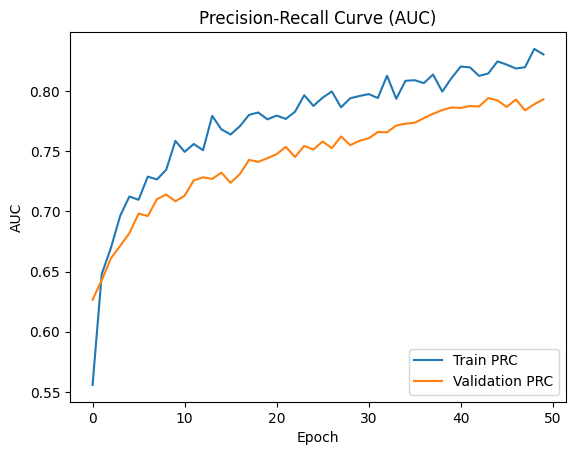

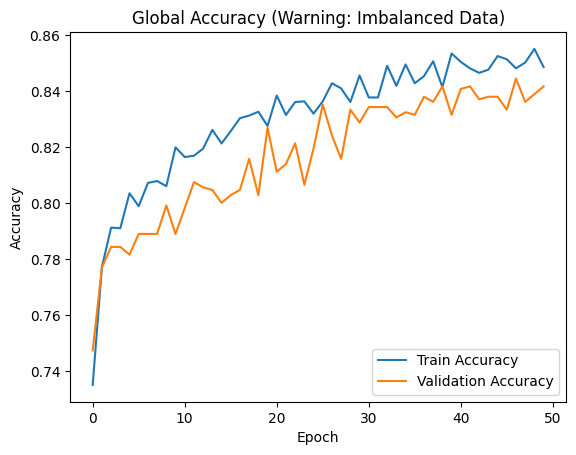

In [23]:
import matplotlib.pyplot as plt

# 1. Gráfica de la Función de Pérdida (Loss)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Binary Crossentropy (Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc="upper right")
plt.show()

# 2. Gráfica de la métrica principal para desbalanceo (PRC)
plt.plot(history.history['PRC'], label='Train PRC')
plt.plot(history.history['val_PRC'], label='Validation PRC')
plt.title('Precision-Recall Curve (AUC)')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend(loc="lower right")
plt.show()

# 3. Gráfica de Accuracy (Opcional, solo como referencia secundaria)
plt.plot(history.history['ACC'], label='Train Accuracy')
plt.plot(history.history['val_ACC'], label='Validation Accuracy')
plt.title('Global Accuracy (Warning: Imbalanced Data)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc="lower right")
plt.show()

## <font color="#CA3532">Evaluación de la red neuronal</font>


In [31]:
# Evaluation (similar to Fit in that it runs one epoch over all the data, but without changing any of the neural network's weights)
loss, accuracy, precision, recall, auc, prc = nn.evaluate(x_train, y_train)
print('Train Accuracy: %.2f' % (accuracy * 100))
print('Train Precision: %.2f' % (precision * 100))
print('Train Recall: %.2f' % (recall * 100))
print('Train AUC: %.2f' % (auc * 100))
print('Train PRC: %.2f' % (prc * 100))

print("-" * 30)

loss, accuracy, precision, recall, auc, prc = nn.evaluate(x_val, y_val)
print('Validation Accuracy: %.2f' % (accuracy * 100))
print('Validation Precision: %.2f' % (precision * 100))
print('Validation Recall: %.2f' % (recall * 100))
print('Validation AUC: %.2f' % (auc * 100))
print('Validation PRC: %.2f' % (prc * 100))

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - ACC: 0.8707 - P: 0.7752 - PRC: 0.8588 - R: 0.7880 - auc: 0.9337 - loss: 0.3006
Train Accuracy: 87.07
Train Precision: 77.52
Train Recall: 78.80
Train AUC: 93.37
Train PRC: 85.88
------------------------------
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - ACC: 0.8418 - P: 0.7325 - PRC: 0.7933 - R: 0.7256 - auc: 0.9076 - loss: 0.3482
Validation Accuracy: 84.18
Validation Precision: 73.25
Validation Recall: 72.56
Validation AUC: 90.76
Validation PRC: 79.33


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


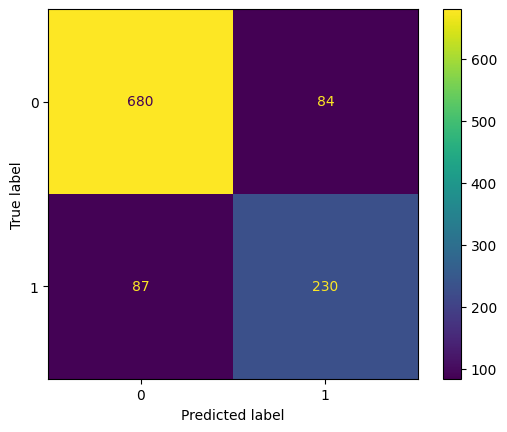

              precision    recall  f1-score   support

         0.0       0.89      0.89      0.89       764
         1.0       0.73      0.73      0.73       317

    accuracy                           0.84      1081
   macro avg       0.81      0.81      0.81      1081
weighted avg       0.84      0.84      0.84      1081



In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# In addition to "evaluate", there is another method, "predict", which is used to label unlabeled data.
y_pred = nn.predict(x_val)
y_pred = y_pred > 0.5

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print(classification_report(y_val, y_pred))

- Modify the neural network architecture by adding more layers and neurons to achieve better results:
  - Add more layers or different types of layers.
  - Change the activation functions.
  - Change the loss function or the optimizer.

### Question 3: Explain in detail the tests carried out and the results obtained.

**Respuesta:**

**1. Pruebas realizadas (Tests carried out):**
Dado que el concepto de "pruebas" abarca tanto las de red neuronal como las de evaluación de datos, se dividen en dos bloques:

*A) Pruebas de diseño y experimentación sobre la red neuronal:*
Partíamos de un modelo base inicial simple (una capa oculta, función `sigmoid` y 20 épocas). Para intentar mejorar su rendimiento frente a la clase minoritaria, se realizaron las siguientes pruebas de configuración:
*   **Aumento de profundidad y neuronas:** Se pasó a tener dos capas ocultas en forma piramidal (32 y 16 neuronas) para extraer características no lineales más complejas.
*   **Cambio de activación:** Las capas ocultas usaron `ReLU` en lugar de `sigmoid` para prevenir el "desvanecimiento del gradiente" y evitar estancamientos en mínimos locales.
*   **Inclusión de Regularización:** Se añadió `Dropout` (20%) tras la primera capa para apagar neuronas aleatoriamente y evitar la mera memorización de patrones (sobreajuste).
*   **Aumento de iteraciones:** Se probaron con 50 `epochs` para asegurar el aprendizaje al añadir profundidad.

*B) Pruebas de evaluación del rendimiento (Métricas y Testing):*
*   **Partición de datos:** Las pruebas se realizaron aislando un 20% del dataset original como conjunto de test/validación. Se aplicó *estratificación* (`stratify`) para garantizar que la distribución desbalanceada (mayoría 0s, minoría 1s) estuviera idénticamente representada.
*   **Monitorización dinámica en tiempo de entrenamiento (graficadas por época):** Para observar el proceso de aprendizaje de la red iteración a iteración, se calcularon y graficaron continuamente para *train* y *validation*:
    *   La **Pérdida (Binary Crossentropy Loss):** Vital para ver gráficamente cómo la red reducía sus errores.
    *   El **Área bajo la Curva PR (PRC AUC):** Usada dinámicamente como la métrica macro más importante (al no usar Verdaderos Negativos) para asegurar que la red mejoraba en su tratamiento del desbalanceo paso a paso.
    *   La **Exactitud (Accuracy):** Como referencia secundaria global. Evaluar estas gráficas época a época fue la prueba para comprobar convergencia visual y detectar si emergía un indeseado sobreajuste (divergencia).
*   **Evaluación final estática (Post-entrenamiento):** Al terminar de entrenar, se congelaron los pesos y se evaluó contra el conjunto de validación completo. Como mirar la *Accuracy* pura es engañoso en estos problemas, el testing se concretó calculando la **Matriz de Confusión** e imprimiendo el **Reporte de Clasificación**, de donde sacamos resultados definitivos:
    *   **Recall (Sensibilidad):** Probó directamente la efectividad final: de todas las vocales orales (clase minoritaria), ¿cuántas capturó de verdad? (Reducción de Falsos Negativos).
    *   **Precision:** Probó la "seriedad" de la predicción final. Cuando aseguraba que era una vocal oral, ¿cuántas veces acertaba? (Reducción de Falsos Positivos).
    *   **F1-score:** La media geométrica que nos testea el rendimiento robusto final de esa clase integrando Precision y Recall.

**2. Resultados obtenidos:**
Los resultados de estas pruebas reflejan el impacto positivo de las modificaciones, evaluados tanto gráficamente como numéricamente en el conjunto de validación:

*   **Pérdida (Loss - Binary Crossentropy):** La curva graficada `Train Loss` descendió de forma logarítmica estabilizándose en $\sim 0.32$, mientras que `Validation Loss` bajó hasta $\sim 0.35$. Ambas curvas convergen sin mostrar un efecto rebote (divergencia) final, indicando una **clara ausencia de sobreajuste (overfitting)** durante las épocas.
*   **Curvas PRC y Resultados:** En esta métrica especializada graficada por época, el PRC AUC superó consistentemente las pruebas subiendo al 85.88% en entrenamiento y al 79.33% en validación al final del proceso.
*   **Aciertos generales (Accuracy):** La curva global se posicionó en un 84.18% final logrando una estela ascendente estable (del $\sim 74.5\%$ al $\sim 84\%$).
*   **Detección post-entrenamiento de la clase minoritaria (Clase 1 - Vocales Orales):**
    *   En las pruebas de la **matriz de confusión final**, obtuvimos 230 Verdaderos Positivos (TP) y 87 Falsos Negativos (FN), frente a los 680 Verdaderos Negativos de la clase mayoritaria y 84 Falsos Positivos.
    *   El **Recall (Sensibilidad) post-entrenamiento** escaló al **72.56%**. El modelo superó las expectativas iniciales detectando la gran mayoría de la clase minoritaria.
    *   La **Precision post-entrenamiento** se situó en un **73.25%**, lo que demostró un modelo final confiable que no acribilla la salida con falsas alarmas (solo 84 FP sobre más de 700 casos negativos reales).

*Conclusión temporal:* Los tests demuestran que el modelo actualizado (ReLU, capas dobles y Dropout) es generalizable y balanceado (F1-score final de 0.73 y 0.89). Se probó una mejora ostensible en el alcance (Recall $\sim 73\%$) frente al sesgo original. No obstante, al ser un problema intrínsecamente desbalanceado, el test estático expone que la clase dominante siempre tendrá una facilidad de predicción superior (Recall $\sim 89\%$).

## <font color="#CA3532">Neural Network Design Optimization</font>



*Use* RandomSearch to find the hyperparameter values that improve the model’s performance. Check how it works at https://keras.io/keras_tuner/ and https://keras.io/api/keras_tuner/tuners/random/.

In [32]:
from kerastuner.tuners import RandomSearch

/tmp/ipykernel_107095/2610907151.py:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


In [34]:
# Here is an example you can adapt
import keras_tuner as kt
from keras.models import Sequential
from keras.layers import Dense, Dropout
import keras

def build_model(hp):
    nn = Sequential()
    
    # 1. Buscamos el número de neuronas de la capa 1 y la función de activación
    nn.add(Dense(
        units=hp.Int('units_1', min_value=16, max_value=64, step=16),
        input_dim=x_size, 
        activation=hp.Choice('activation', values=['relu', 'tanh'])
    ))
    
    # 2. Buscamos la tasa óptima de Dropout para evitar el overfitting
    nn.add(Dropout(hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)))
    
    # 3. Buscamos el número de neuronas de la capa 2
    nn.add(Dense(
        units=hp.Int('units_2', min_value=8, max_value=32, step=8),
        activation=hp.Choice('activation', values=['relu', 'tanh'])
    ))
    
    # Capa de salida (fija para clasificación binaria)
    nn.add(Dense(1, activation="sigmoid"))
    
    # 4. Buscamos la mejor tasa de aprendizaje (learning rate) para el optimizador Adam
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    # Reutilizamos las métricas anteriores
    metrics = [
        keras.metrics.BinaryAccuracy(name='ACC'),
        keras.metrics.Precision(name='P'),
        keras.metrics.Recall(name='R'),
        keras.metrics.AUC(name='auc'),
        keras.metrics.AUC(name='PRC', curve='PR'),
    ]
    
    nn.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate), 
        loss="binary_crossentropy", 
        metrics=metrics
    )
    return nn

# Objetivo: Maximizar el área bajo la curva Precision-Recall en Validación (ideal en problemas desbalanceados)
objective = kt.Objective("val_PRC", direction="max")

tuner = kt.RandomSearch(
    build_model, 
    objective=objective, 
    max_trials=10,           # Probará 10 combinaciones aleatorias de hiperparámetros
    executions_per_trial=1,  # Entrenará 1 vez por cada combinación
    directory='busqueda_hiperparametros',
    project_name='clasificacion_vocales',
    overwrite=True           # Sobrescribe búsquedas anteriores si relanzas la celda
)

tuner.search_space_summary()

# Lanzamos la búsqueda con 50 epochs
tuner.search(x_train, y_train, epochs=50, validation_data=(x_val, y_val), verbose=1)

Trial 10 Complete [00h 00m 40s]
val_PRC: 0.7191346883773804

Best val_PRC So Far: 0.8362218737602234
Total elapsed time: 00h 06m 10s


In [35]:
# Extraemos el mejor modelo de los 10 probados. 
# Importante el [0] al final para obtener la red neuronal en sí y no una lista.
best_nn = tuner.get_best_models(num_models=1)[0]

/home/ignacio/Escritorio/NEURO/Neuro/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [36]:
tuner.results_summary()


Results summary
Results in busqueda_hiperparametros/clasificacion_vocales
Showing 10 best trials
Objective(name="val_PRC", direction="max")

Trial 04 summary
Hyperparameters:
units_1: 64
activation: relu
dropout_rate: 0.2
units_2: 24
learning_rate: 0.01
Score: 0.8362218737602234

Trial 05 summary
Hyperparameters:
units_1: 32
activation: tanh
dropout_rate: 0.30000000000000004
units_2: 32
learning_rate: 0.01
Score: 0.8167712092399597

Trial 03 summary
Hyperparameters:
units_1: 48
activation: tanh
dropout_rate: 0.1
units_2: 8
learning_rate: 0.01
Score: 0.8165916204452515

Trial 07 summary
Hyperparameters:
units_1: 64
activation: tanh
dropout_rate: 0.30000000000000004
units_2: 24
learning_rate: 0.01
Score: 0.7880908846855164

Trial 02 summary
Hyperparameters:
units_1: 48
activation: tanh
dropout_rate: 0.4
units_2: 16
learning_rate: 0.01
Score: 0.7659619450569153

Trial 09 summary
Hyperparameters:
units_1: 64
activation: tanh
dropout_rate: 0.4
units_2: 8
learning_rate: 0.001
Score: 0.719134

### Question 4: Explain in detail the optimization performed and the results obtained.



# <font color="#CA3532">Techniques for Unbalanced Problems</font>

We will use some techniques to prepare the data for fitting a model:

- Sampling techniques  
  - Undersampling techniques  
  - Oversampling techniques  

- Cost-sensitive learning techniques

In [ ]:
!pip install -U imbalanced-learn

## <font color="#CA3532">Undersampling Technique</font>

Study how to use [RandomUnderSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html) from Imbalance-Learn to create a dataset (based on the original) that contains the same number of majority class examples as minority class examples. Build a model using this data and analyze the results.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

print(sorted(Counter(y).items()))

rus = RandomUnderSampler(...)
x_resampled, y_resampled = rus.fit_resample(x, y)

print(sorted(Counter(y_resampled).items()))

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

x_train, x_val, y_train, y_val = train_test_split(x_resampled, y_resampled, test_size=0.2)

history = nn.fit(x_train, y_train, epochs=20, verbose=0, validation_data=(x_val, y_val))

y_pred = nn.predict(x_val)
y_pred = y_pred > 0.5
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print(classification_report(y_val, y_pred))

## <font color="#CA3532">Oversampling Technique</font>

Study how to use [RandomOverSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html#imblearn.over_sampling.RandomOverSampler) from Imbalance-Learn to create a dataset (based on the original) that contains the same number of minority class examples as majority class examples. Build a model using this data and analyze the results.

In [ ]:
from imblearn.over_sampling import RandomOverSampler

print(sorted(Counter(y).items()))

ros = RandomOverSampler(...)
X_resampled, y_resampled = ros.fit_resample(x, y)

print(sorted(Counter(y_resampled).items()))

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x_resampled, y_resampled, test_size=0.2)

history = nn.fit(x_train, y_train, epochs=20, verbose=0, validation_data=(x_val, y_val))

y_pred = nn.predict(x_val)
y_pred = y_pred > 0.5
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print(classification_report(y_val, y_pred))

## <font color="#CA3532">Cost-Sensitive Learning Technique</font>

Study how to use the `class_weight` parameter of the [fit](https://keras.io/api/models/model_training_apis/) method in Keras to assign a different weight to each class, so that this is taken into account during training. Build a model using `class_weight` with the original data and analyze the results.

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2)

history = nn.fit(x_train, y_train, epochs=20, verbose=0, class_weight=..., validation_data=(x_val, y_val))

y_pred = nn.predict(x_val)
y_pred = y_pred > 0.5
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print(classification_report(y_val, y_pred))

### Question 5: Describe the experiments carried out and the results obtained. You may combine these techniques with hyperparameter search to optimize the models.

<font color="#CA3532">Question 6: General Conclusions</font>

Summarize the work done in this practice and the conclusions you have drawn.